
# Neyman–Pearson Lemma Notes and Python Examples

## 1. Introduction

The **Neyman–Pearson Lemma** is a fundamental theorem in statistical hypothesis testing.

It provides the **most powerful test** for testing:

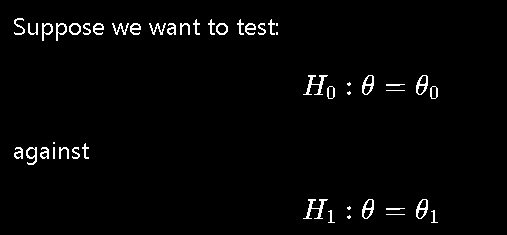
\]

where both hypotheses are **simple hypotheses**.


The Neyman–Pearson lemma states that the Likelihood Ratio Test (LRT) is the most powerful test at significance level α.

---

# 2. Likelihood Ratio

The likelihood ratio is:



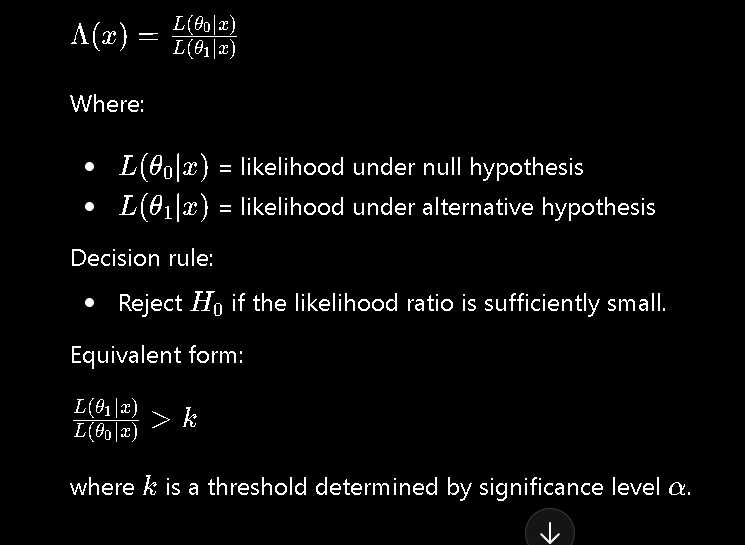
.

---

# 3. Important Concepts

## Simple Hypothesis

A hypothesis with one parameter value.

Example:

\[
H_0: p = 0.5
\]

---

## Significance Level

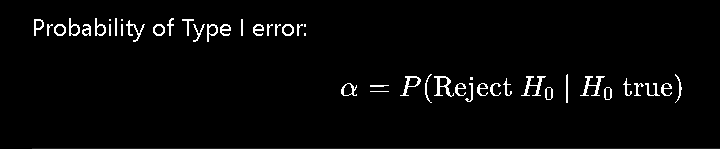
---

## Power of Test

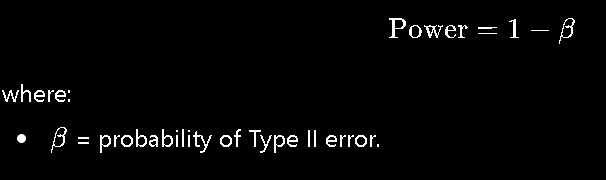

---

# 4. Steps in Neyman–Pearson Testing

1. Define hypotheses
2. Write likelihood functions
3. Form likelihood ratio
4. Determine rejection region
5. Compare with critical value
6. Make decision

---

# Example 1: Coin Toss (Binomial)

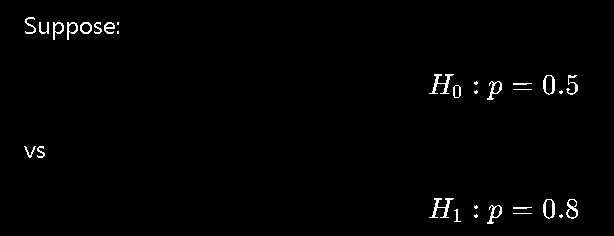

A coin is tossed \(n=10\) times.

Observed heads:

\[
x = 8
\]

Likelihood:

\[
L(p|x)=\binom{n}{x}p^x(1-p)^{n-x}
\]

Likelihood ratio:

\[
\frac{L(0.8|x)}{L(0.5|x)}=
\frac{0.8^x(0.2)^{10-x}}{0.5^{10}}
\]



In [ ]:

#Code
#import numpy as np
from scipy.stats import binom

# Hypotheses
p0 = 0.5
p1 = 0.8

# Observed number of heads
x = 8
n = 10

# Likelihoods
L0 = binom.pmf(x, n, p0)
L1 = binom.pmf(x, n, p1)

# Likelihood ratio
LR = L1 / L0

print("Likelihood under H0:", L0)
print("Likelihood under H1:", L1)
print("Likelihood Ratio:", LR)

if LR > 1:
    print("Evidence favors H1")
else:
    print("Evidence favors H0")



# Example 2: Normal Distribution

Suppose:

\[
H_0: \mu = 50
\]

vs

\[
H_1: \mu = 55
\]

Assume:

- \(\sigma = 10\)
- \(n = 25\)
- \(\bar{x}=54\)

Z-statistic:

\[
Z=\frac{\bar{X}-\mu_0}{\sigma/\sqrt{n}}
\]



In [ ]:

import numpy as np
from scipy.stats import norm

# Parameters
mu0 = 50
mu1 = 55
sigma = 10
n = 25
xbar = 54

# Standard error
SE = sigma / np.sqrt(n)

# Z statistic
z = (xbar - mu0) / SE

# p-value
p_value = 1 - norm.cdf(z)

print("Z-statistic:", z)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")



# Example 3: Poisson Distribution

Suppose:

\[
H_0: \lambda = 2
\]

vs

\[
H_1: \lambda = 5
\]

Observed defects:

\[
x = 6
\]

Poisson likelihood:

\[
L(\lambda|x)=\frac{e^{-\lambda}\lambda^x}{x!}
\]



In [ ]:

from scipy.stats import poisson

# Parameters
x = 6
lambda0 = 2
lambda1 = 5

# Likelihoods
L0 = poisson.pmf(x, lambda0)
L1 = poisson.pmf(x, lambda1)

# Likelihood ratio
LR = L1 / L0

print("Likelihood under H0:", L0)
print("Likelihood under H1:", L1)
print("Likelihood Ratio:", LR)

if LR > 1:
    print("Reject H0")
else:
    print("Fail to reject H0")



# Example 4: Exponential Distribution

Suppose:

\[
H_0: \lambda = 0.5
\]

vs

\[
H_1: \lambda = 1.0
\]

Observed lifetime:

\[
x = 0.2
\]

Likelihood:

\[
L(\lambda|x)=\lambda e^{-\lambda x}
\]



In [ ]:

import numpy as np

# Parameters
x = 0.2
lambda0 = 0.5
lambda1 = 1.0

# Likelihoods
L0 = lambda0 * np.exp(-lambda0 * x)
L1 = lambda1 * np.exp(-lambda1 * x)

# Likelihood ratio
LR = L1 / L0

print("Likelihood under H0:", L0)
print("Likelihood under H1:", L1)
print("Likelihood Ratio:", LR)

if LR > 1:
    print("Reject H0")
else:
    print("Fail to reject H0")



# Example 5: Visualization of Likelihood Ratio

This example visualizes the likelihood ratio.



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters
n = 20
p0 = 0.5
p1 = 0.7

# X values
x = np.arange(0, n+1)

# Likelihood ratio
LR = binom.pmf(x, n, p1) / binom.pmf(x, n, p0)

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, LR, marker='o')

plt.xlabel("Number of Successes")
plt.ylabel("Likelihood Ratio")
plt.title("Likelihood Ratio Test")

plt.grid(True)
plt.show()



# Example 6: Finding Critical Region

Suppose:

\[
H_0: p = 0.5
\]

vs

\[
H_1: p = 0.8
\]

with \(n=10\).



In [ ]:

from scipy.stats import binom

n = 10
p0 = 0.5

for k in range(n + 1):

    # Type I error
    type1_error = 1 - binom.cdf(k - 1, n, p0)

    print(f"k={k}, alpha={type1_error:.4f}")



# Example 7: Comparing Power of Two Tests

Power measures the probability of correctly rejecting a false null hypothesis.



In [ ]:

from scipy.stats import binom

n = 10
p1 = 0.8

# Test 1
power1 = 1 - binom.cdf(7, n, p1)

# Test 2
power2 = 1 - binom.cdf(8, n, p1)

print("Power of Test 1:", power1)
print("Power of Test 2:", power2)



# Summary

The Neyman–Pearson Lemma states:

> The likelihood ratio test is the most powerful test for testing a simple null hypothesis against a simple alternative hypothesis.

Core idea:

\[
\frac{L(H_1)}{L(H_0)}
\]

Reject \(H_0\) when the ratio strongly favors \(H_1\).

---

# Common Distributions Used

- Binomial
- Normal
- Poisson
- Exponential

---

# Applications

- Hypothesis testing
- Machine learning
- Signal detection
- Statistical inference
